# Step 2: MLP + Backpropagation

A **Multi-Layer Perceptron** stacks multiple neuron layers. The output of one layer
becomes the input of the next. With at least one **hidden layer**, an MLP can represent
any continuous function (Universal Approximation Theorem).

**The key enabler**: backpropagation — efficient computation of gradients through
the chain rule of calculus. Every weight gets a gradient telling it which direction
to move to reduce the loss.

**What you'll see:**
1. Manual forward and backward pass — every step in NumPy
2. XOR solved (impossible for a single neuron)
3. Decision boundary evolving during training
4. The vanishing gradient problem emerging with sigmoid + depth

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def sigmoid_grad(z): s = sigmoid(z); return s * (1 - s)

## The Architecture

```
Input (2)  →  Hidden (4, sigmoid)  →  Output (1, sigmoid)

Forward pass:
  z1 = X @ W1 + b1        # shape: (N, 4)
  a1 = sigmoid(z1)        # shape: (N, 4)
  z2 = a1 @ W2 + b2       # shape: (N, 1)
  yhat = sigmoid(z2)      # shape: (N, 1)

Loss: L = -mean[y log(yhat) + (1-y) log(1-yhat)]

Backward pass (chain rule, right to left):
  dL/dz2 = yhat - y
  dL/dW2 = a1.T @ dL/dz2
  dL/db2 = sum(dL/dz2)
  dL/da1 = dL/dz2 @ W2.T
  dL/dz1 = dL/da1 * sigmoid_grad(z1)
  dL/dW1 = X.T @ dL/dz1
  dL/db1 = sum(dL/dz1)
```

In [1]:
class MLP:
    """2-layer MLP with manual forward and backward pass."""

    def __init__(self, n_input, n_hidden, n_output, lr=0.5):
        # Xavier initialization: keeps activations near unit variance early in training
        self.W1 = np.random.randn(n_input, n_hidden) * np.sqrt(2 / n_input)
        self.b1 = np.zeros(n_hidden)
        self.W2 = np.random.randn(n_hidden, n_output) * np.sqrt(2 / n_hidden)
        self.b2 = np.zeros(n_output)
        self.lr = lr

    def forward(self, X):
        """Forward pass: return output and cache intermediate values for backprop."""
        self.X = X
        self.z1 = X @ self.W1 + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.yhat = sigmoid(self.z2)
        return self.yhat

    def backward(self, y):
        """Backward pass: compute gradients and update weights."""
        N = len(y)
        y = y.reshape(-1, 1)

        # Output layer gradients
        # For sigmoid + cross-entropy, gradient simplifies to (yhat - y)
        dz2 = (self.yhat - y) / N         # (N, 1)
        dW2 = self.a1.T @ dz2             # (n_hidden, 1)
        db2 = dz2.sum(axis=0)             # (1,)

        # Hidden layer gradients — this is the chain rule in action
        da1 = dz2 @ self.W2.T             # (N, n_hidden)
        dz1 = da1 * sigmoid_grad(self.z1) # (N, n_hidden)  ← sigmoid grad here
        dW1 = self.X.T @ dz1             # (n_input, n_hidden)
        db1 = dz1.sum(axis=0)            # (n_hidden,)

        # Gradient descent step
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

        # Return gradient norms for inspection
        return {'|dW2|': np.linalg.norm(dW2), '|dW1|': np.linalg.norm(dW1)}

    def loss(self, y):
        y = y.reshape(-1, 1)
        return -np.mean(y * np.log(self.yhat + 1e-9) + (1-y) * np.log(1-self.yhat + 1e-9))

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int).flatten()

In [1]:
# XOR dataset — impossible for a single neuron
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

mlp = MLP(n_input=2, n_hidden=4, n_output=1, lr=2.0)

losses = []
grad_norms_W1 = []
grad_norms_W2 = []
snapshots = {}     # Save weight states for boundary visualization

for epoch in range(5000):
    mlp.forward(X)
    grads = mlp.backward(y_xor)
    losses.append(mlp.loss(y_xor))
    grad_norms_W1.append(grads['|dW1|'])
    grad_norms_W2.append(grads['|dW2|'])
    if epoch in [0, 50, 200, 500, 5000-1]:
        snapshots[epoch] = (mlp.W1.copy(), mlp.b1.copy(), mlp.W2.copy(), mlp.b2.copy())

print(f"Final loss: {losses[-1]:.6f}")
print(f"Final predictions: {mlp.predict(X)}")
print(f"True labels:       {y_xor.astype(int)}")

Final loss: 0.000904
Final predictions: [0 1 1 0]
True labels:       [0 1 1 0]


<string>:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


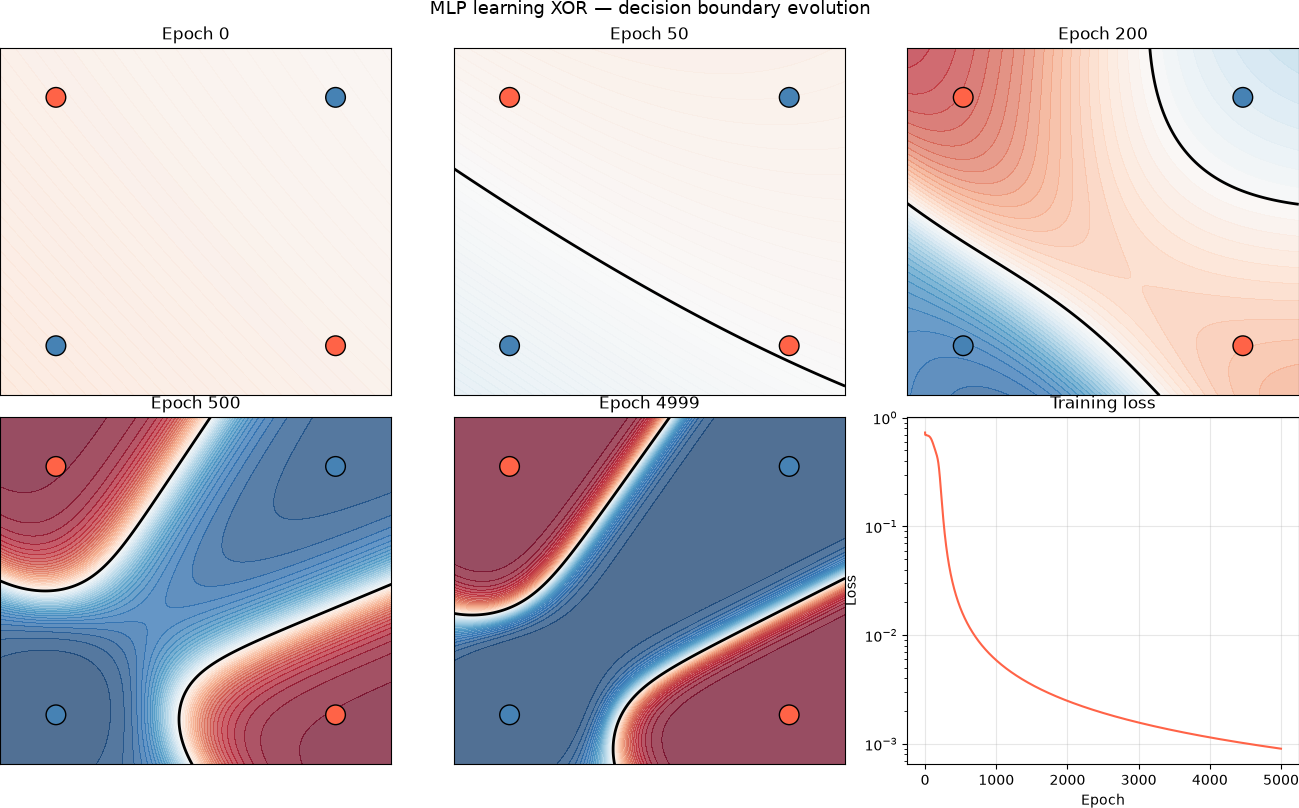

In [1]:
def plot_boundary_snapshot(ax, W1, b1, W2, b2, X, y, title):
    """Plot the model's decision boundary at a given training snapshot."""
    xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 200), np.linspace(-0.2, 1.2, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    a1 = sigmoid(grid @ W1 + b1)
    zz = sigmoid(a1 @ W2 + b2).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=50, cmap='RdBu_r', alpha=0.7, vmin=0, vmax=1)
    ax.contour(xx, yy, zz, levels=[0.5], colors='k', linewidths=2)
    colors = ['steelblue' if yi == 0 else 'tomato' for yi in y]
    ax.scatter(X[:,0], X[:,1], c=colors, s=200, zorder=3, edgecolors='k')
    ax.set_title(title); ax.set_xlim(-0.2, 1.2); ax.set_ylim(-0.2, 1.2)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for ax, (epoch, (W1, b1, W2, b2)) in zip(axes.flat, snapshots.items()):
    plot_boundary_snapshot(ax, W1, b1, W2, b2, X, y_xor, f'Epoch {epoch}')

# Training loss in the last panel
ax = axes.flat[len(snapshots)]
ax.plot(losses, 'tomato', lw=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training loss')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.suptitle('MLP learning XOR — decision boundary evolution', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Visualizing the Vanishing Gradient Problem

Each time a gradient passes through a sigmoid layer, it's multiplied by σ'(z) ≤ 0.25.
For a network with L layers:

```
gradient at layer 1 ≈ gradient at output × 0.25^(L-1)
```

For L=10: gradient is multiplied by 0.25^9 ≈ 3.8 × 10⁻⁶

Early layers learn exponentially more slowly than later layers.
This is why sigmoid networks are hard to train when deep.

Ratio of layer-8 to layer-1 gradient: 768.378125


<string>:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


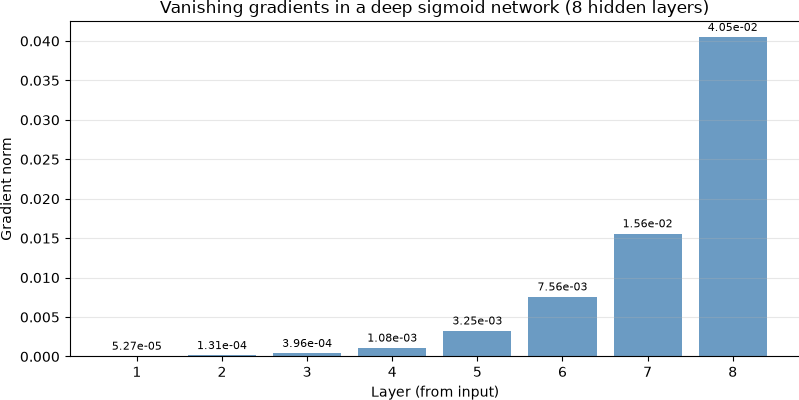

In [1]:
# Demonstrate vanishing gradients by building a deep sigmoid network
# and measuring gradient magnitudes at each layer

def deep_sigmoid_forward_backward(X, y, n_layers=8, n_units=16):
    """Forward + backward pass through a deep sigmoid network; return per-layer gradient norms."""
    # Initialize weights
    layers = []
    dims = [X.shape[1]] + [n_units] * n_layers + [1]
    for i in range(len(dims)-1):
        W = np.random.randn(dims[i], dims[i+1]) * 0.5
        b = np.zeros(dims[i+1])
        layers.append((W, b))

    # Forward pass, saving pre-activations
    activations = [X]
    pre_acts = []
    a = X
    for W, b in layers[:-1]:
        z = a @ W + b
        pre_acts.append(z)
        a = sigmoid(z)
        activations.append(a)
    # Output layer (sigmoid)
    W, b = layers[-1]
    z_out = a @ W + b
    yhat = sigmoid(z_out)

    # Backward pass
    grad = (yhat - y.reshape(-1, 1)) / len(y)
    grad_norms = []
    for i in range(len(layers)-1, 0, -1):
        W, b = layers[i]
        grad_norms.append(np.linalg.norm(grad))
        dW = activations[i].T @ grad
        grad = grad @ W.T
        grad = grad * sigmoid_grad(pre_acts[i-1])

    return list(reversed(grad_norms))

# Use a larger XOR-like dataset so gradients are more stable
np.random.seed(0)
N = 200
X_large = np.random.randn(N, 2)
y_large = ((X_large[:,0] > 0) ^ (X_large[:,1] > 0)).astype(float)

grad_norms = deep_sigmoid_forward_backward(X_large, y_large, n_layers=8)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(grad_norms)+1), grad_norms, color='steelblue', alpha=0.8)
ax.set_xlabel('Layer (from input)')
ax.set_ylabel('Gradient norm')
ax.set_title('Vanishing gradients in a deep sigmoid network (8 hidden layers)')
ax.set_xticks(range(1, len(grad_norms)+1))
ax.grid(True, alpha=0.3, axis='y')

for i, gn in enumerate(grad_norms):
    ax.text(i+1, gn + max(grad_norms)*0.02, f'{gn:.2e}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print(f"Ratio of layer-8 to layer-1 gradient: {grad_norms[-1]/grad_norms[0]:.6f}")

## Why the Chain Rule Is the Key

Backpropagation is not a special algorithm — it is just the **chain rule of calculus**
applied systematically from the output back to the inputs:

```
∂L/∂W₁ = ∂L/∂ŷ · ∂ŷ/∂z₂ · ∂z₂/∂a₁ · ∂a₁/∂z₁ · ∂z₁/∂W₁
         =  (ŷ-y)   ·  σ'(z₂)  ·     W₂ᵀ     ·  σ'(z₁) ·    X
```

The crucial insight (Rumelhart, Hinton & Williams, 1986): these partial derivatives
can be computed efficiently by reusing intermediate values from the forward pass.
Time complexity is O(parameters) — the same as a single forward pass.

**What's still missing**: sigmoid networks suffer from vanishing gradients at depth.
The next developments — ReLU activations and batch normalization — address this.
But first, we need to handle **sequences**.

## Key Takeaways

| Concept | What we learned |
|---|---|
| **Hidden layer** | Enables nonlinear decision boundaries; solves XOR |
| **Forward pass** | Compose linear transforms + nonlinear activations |
| **Backward pass** | Chain rule, right to left; O(params) computation |
| **Xavier init** | Scale weights to preserve activation variance at initialization |
| **Vanishing gradient** | Sigmoid gradient ≤ 0.25; compounds across layers exponentially |
| **Gradient descent** | Subtract lr × gradient from each weight |

**What's still missing**: this MLP treats all inputs independently. 
It can't process **sequences** where order and context matter. Next: CNNs and then RNNs.